In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

county = pd.read_csv(
    "../data/processed/coverage_ratio_2024.csv",
    dtype={"fips": str}
)

print("Shape:", county.shape)

print("\nMissing values:")
print(county.isna().sum())

display(
    county[
        [
            "County",
            "visits",
            "expected_visits",
            "coverage_ratio"
        ]
    ].head()
)

Shape: (86, 30)

Missing values:
County                   0
fips                     0
visits                   0
individuals              0
pounds                   0
need_people_month        0
population               0
visits_per_1000          0
poverty_rate             0
snap_hh_rate             0
poor_no_snap_rate        0
med_income               0
no_vehicle_rate          0
rucc                     0
metro                    0
main_food_bank           0
report_share             0
food_insecure_people     0
food_insecurity_rate     0
benchmark_use_rate       0
expected_unscaled        0
expected_visits          0
coverage_ratio           0
alt_use_rate             0
alt_expected_unscaled    0
alt_expected_visits      0
alt_coverage_ratio       0
baseline_rank            0
alternative_rank         0
rank_change              0
dtype: int64


,County,visits,expected_visits,coverage_ratio
0,Aitkin,330.916667,739.739053,0.447342
1,Anoka,19465.083333,14332.082579,1.358148
2,Becker,543.750000,1560.666580,0.348409
3,Beltrami,1250.333333,2141.679498,0.583810
4,Benton,673.083333,1794.669680,0.375046


annual visits=12xaverage monthly visits

In [2]:
county["annual_visits"] = (
    county["visits"] * 12
).round().astype(int)

county["expected_annual_visits"] = (
    county["expected_visits"] * 12
)

county["log_expected_annual"] = np.log(
    county["expected_annual_visits"]
)

display(
    county[
        [
            "County",
            "annual_visits",
            "expected_annual_visits",
            "coverage_ratio"
        ]
    ].head()
)

print(
    "Minimum annual visits:",
    county["annual_visits"].min()
)

print(
    "All expected values positive:",
    (county["expected_annual_visits"] > 0).all()
)

,County,annual_visits,expected_annual_visits,coverage_ratio
0,Aitkin,3971,8876.868635,0.447342
1,Anoka,233581,171984.990952,1.358148
2,Becker,6525,18727.998962,0.348409
3,Beltrami,15004,25700.153975,0.583810
4,Benton,8077,21536.036162,0.375046


Minimum annual visits: 546
All expected values positive: True


\[
\log E(O_i)
=
\log(E_i)+\beta_0
\]
where:
- \(O_i\) = observed annual visits
- \(E_i\) = expected annual visits
- log_expected_annual is the offset
- \(\beta_0\) is the only ordinary coefficient.

In [3]:
m0 = smf.negativebinomial(
    formula="annual_visits ~ 1",
    data=county,
    offset=county["log_expected_annual"]
).fit()

print(m0.summary())

Optimization terminated successfully.
         Current function value: 9.848492
         Iterations: 9
         Function evaluations: 11
         Gradient evaluations: 11
                     NegativeBinomial Regression Results                      
Dep. Variable:          annual_visits   No. Observations:                   86
Model:               NegativeBinomial   Df Residuals:                       85
Method:                           MLE   Df Model:                            0
Date:                Thu, 08 Oct 2026   Pseudo R-squ.:               1.430e-12
Time:                        14:43:37   Log-Likelihood:                -846.97
converged:                       True   LL-Null:                       -846.97
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3997      0.063     -6

After starting each county at its need-based expected activity, are differences in transportation and rurality associated with how much activity is actually recorded?

In [4]:
m1 = smf.negativebinomial(
    formula=(
        "annual_visits ~ "
        "no_vehicle_rate + rucc"
    ),
    data=county,
    offset=county["log_expected_annual"]
).fit()

print(m1.summary())

print("\nM0 AIC:", m0.aic)
print("M1 AIC:", m1.aic)
print("AIC improvement:", m0.aic - m1.aic)

rucc_beta = m1.params["rucc"]

rucc_one_step = (
    np.exp(rucc_beta) - 1
) * 100

rucc_full_range = (
    np.exp(8 * rucc_beta) - 1
) * 100

print(
    "Percent change for one RUCC step:",
    rucc_one_step
)

print(
    "Percent change from RUCC 1 to 9:",
    rucc_full_range
)

Optimization terminated successfully.
         Current function value: 9.802027
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     NegativeBinomial Regression Results                      
Dep. Variable:          annual_visits   No. Observations:                   86
Model:               NegativeBinomial   Df Residuals:                       83
Method:                           MLE   Df Model:                            2
Date:                Thu, 08 Oct 2026   Pseudo R-squ.:                0.004718
Time:                        14:43:37   Log-Likelihood:                -842.97
converged:                       True   LL-Null:                       -846.97
Covariance Type:            nonrobust   LLR p-value:                   0.01839
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.3246  

In [5]:
m2 = smf.negativebinomial(
    formula=(
        "annual_visits ~ "
        "no_vehicle_rate + "
        "rucc + "
        'C(main_food_bank, '
        'Treatment(reference="Second Harvest Heartland"))'
    ),
    data=county,
    offset=county["log_expected_annual"]
).fit()

print(m2.summary())

print("\nM0 AIC:", m0.aic)
print("M1 AIC:", m1.aic)
print("M2 AIC:", m2.aic)

print(
    "\nImprovement M0 to M1:",
    m0.aic - m1.aic
)

print(
    "Improvement M1 to M2:",
    m1.aic - m2.aic
)

bank_effects = pd.DataFrame({
    "Food bank": [
        "Channel One Regional Food Bank",
        "North Country Food Bank",
        "Second Harvest Northland",
        "The Food Group"
    ],
    "Coefficient": [
        m2.params[
            'C(main_food_bank, Treatment(reference="Second Harvest Heartland"))[T.Channel One Regional Food Bank*]'
        ],
        m2.params[
            'C(main_food_bank, Treatment(reference="Second Harvest Heartland"))[T.North Country Food Bank]'
        ],
        m2.params[
            'C(main_food_bank, Treatment(reference="Second Harvest Heartland"))[T.Second Harvest Northland]'
        ],
        m2.params[
            'C(main_food_bank, Treatment(reference="Second Harvest Heartland"))[T.The Food Group]'
        ]
    ]
})

bank_effects["Percent difference"] = (
    np.exp(bank_effects["Coefficient"]) - 1
) * 100

display(bank_effects)

Optimization terminated successfully.
         Current function value: 9.679660
         Iterations: 29
         Function evaluations: 33
         Gradient evaluations: 33
                     NegativeBinomial Regression Results                      
Dep. Variable:          annual_visits   No. Observations:                   86
Model:               NegativeBinomial   Df Residuals:                       79
Method:                           MLE   Df Model:                            6
Date:                Thu, 08 Oct 2026   Pseudo R-squ.:                 0.01714
Time:                        14:43:37   Log-Likelihood:                -832.45
converged:                       True   LL-Null:                       -846.97
Covariance Type:            nonrobust   LLR p-value:                 5.981e-05
                                                                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

,Food bank,Coefficient,Percent difference
0,Channel One Regional Food Bank,0.572060,77.191375
1,North Country Food Bank,-0.227191,-20.323107
2,Second Harvest Northland,0.219862,24.590481
3,The Food Group,0.684231,98.224692


In [6]:
m3 = smf.negativebinomial(
    formula=(
        "annual_visits ~ "
        "no_vehicle_rate + "
        "rucc + "
        "report_share + "
        'C(main_food_bank, '
        'Treatment(reference="Second Harvest Heartland"))'
    ),
    data=county,
    offset=county["log_expected_annual"]
).fit()

print(m3.summary())

print("\nM2 AIC:", m2.aic)
print("M3 AIC:", m3.aic)
print(
    "Improvement M2 to M3:",
    m2.aic - m3.aic
)

         Current function value: 9.668602
         Iterations: 35
         Function evaluations: 40
         Gradient evaluations: 40
                     NegativeBinomial Regression Results                      
Dep. Variable:          annual_visits   No. Observations:                   86
Model:               NegativeBinomial   Df Residuals:                       78
Method:                           MLE   Df Model:                            7
Date:                Thu, 08 Oct 2026   Pseudo R-squ.:                 0.01827
Time:                        14:43:37   Log-Likelihood:                -831.50
converged:                      False   LL-Null:                       -846.97
Covariance Type:            nonrobust   LLR p-value:                 6.375e-05
                                                                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

c:\Python310\lib\site-packages\scipy\optimize\_optimize.py:1313: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [7]:
#m3 didnt converge refitting here

m3_check = smf.negativebinomial(
    formula=(
        "annual_visits ~ "
        "no_vehicle_rate + "
        "rucc + "
        "report_share + "
        'C(main_food_bank, '
        'Treatment(reference="Second Harvest Heartland"))'
    ),
    data=county,
    offset=county["log_expected_annual"]
).fit(
    method="lbfgs",
    maxiter=500,
    disp=False
)

print(m3_check.summary())

print("\nConverged:", m3_check.mle_retvals["converged"])
print("M2 AIC:", m2.aic)
print("M3 AIC:", m3_check.aic)
print(
    "Improvement M2 to M3:",
    m2.aic - m3_check.aic
)

                     NegativeBinomial Regression Results                      
Dep. Variable:          annual_visits   No. Observations:                   86
Model:               NegativeBinomial   Df Residuals:                       78
Method:                           MLE   Df Model:                            7
Date:                Thu, 08 Oct 2026   Pseudo R-squ.:                 0.01827
Time:                        14:43:37   Log-Likelihood:                -831.50
converged:                       True   LL-Null:                       -846.97
Covariance Type:            nonrobust   LLR p-value:                 6.374e-05
                                                                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                   

Model selection: Adding reporting share in M3 did not improve model fit. M2 had an AIC of 1680.90 compared with 1681.00 for M3, and the reporting-share coefficient was not statistically significant (\(p=0.183\)). Therefore, M2 is retained as the preferred explanatory model because it is more parsimonious. Reporting quality is still used as a diagnostic flag for individual counties, particularly where missing or zero reports are common.

## Funnel plot: separating unusual coverage from statistical variation

In [8]:
alpha_m2 = m2.params["alpha"]

county["log_coverage_ratio"] = np.log(
    county["coverage_ratio"]
)

county["funnel_se"] = np.sqrt(
    (1 / county["expected_annual_visits"])
    + alpha_m2
)

county["lower_95_log"] = (
    -1.96 * county["funnel_se"]
)

county["upper_95_log"] = (
    1.96 * county["funnel_se"]
)

county["lower_95_ratio"] = np.exp(
    county["lower_95_log"]
)

county["upper_95_ratio"] = np.exp(
    county["upper_95_log"]
)

print("M2 alpha:", alpha_m2)

display(
    county[
        [
            "County",
            "expected_annual_visits",
            "coverage_ratio",
            "lower_95_ratio",
            "upper_95_ratio"
        ]
    ].head()
)

M2 alpha: 0.24743200927040082


,County,expected_annual_visits,coverage_ratio,lower_95_ratio,upper_95_ratio
0,Aitkin,8876.868635,0.447342,0.377126,2.651633
1,Anoka,171984.990952,1.358148,0.377205,2.651075
2,Becker,18727.998962,0.348409,0.377170,2.651323
3,Beltrami,25700.153975,0.583810,0.377181,2.651248
4,Benton,21536.036162,0.375046,0.377175,2.651287


In [9]:
county["funnel_status"] = "Within limits"

county.loc[
    county["coverage_ratio"]
    < county["lower_95_ratio"],
    "funnel_status"
] = "Below lower limit"

county.loc[
    county["coverage_ratio"]
    > county["upper_95_ratio"],
    "funnel_status"
] = "Above upper limit"

print(
    county["funnel_status"].value_counts()
)

print("\nCounties below lower limit:")

display(
    county[
        county["funnel_status"]
        == "Below lower limit"
    ][
        [
            "County",
            "coverage_ratio",
            "expected_annual_visits",
            "report_share"
        ]
    ]
    .sort_values("coverage_ratio")
)

print("\nCounties above upper limit:")

display(
    county[
        county["funnel_status"]
        == "Above upper limit"
    ][
        [
            "County",
            "coverage_ratio",
            "expected_annual_visits",
            "report_share"
        ]
    ]
    .sort_values(
        "coverage_ratio",
        ascending=False
    )
)

funnel_status
Within limits        69
Below lower limit    16
Above upper limit     1
Name: count, dtype: int64

Counties below lower limit:


,County,coverage_ratio,expected_annual_visits,report_share
68,Scott,0.111418,67897.379066,0.950000
60,Pope,0.150499,5681.115047,1.000000
51,Nicollet,0.165709,17096.253852,1.000000
53,Norman,0.168078,3248.493801,0.958333
36,Lac qui Parle,0.181299,3326.003379,1.000000
74,Stevens,0.260931,5100.972708,0.750000
7,Brown,0.275891,12747.798045,1.000000
67,Roseau,0.284817,7734.781858,1.000000
20,Douglas,0.287787,19552.633469,1.000000
75,Swift,0.334892,5476.388662,1.000000



Counties above upper limit:


,County,coverage_ratio,expected_annual_visits,report_share
73,Steele,3.201459,18489.067264,1.0


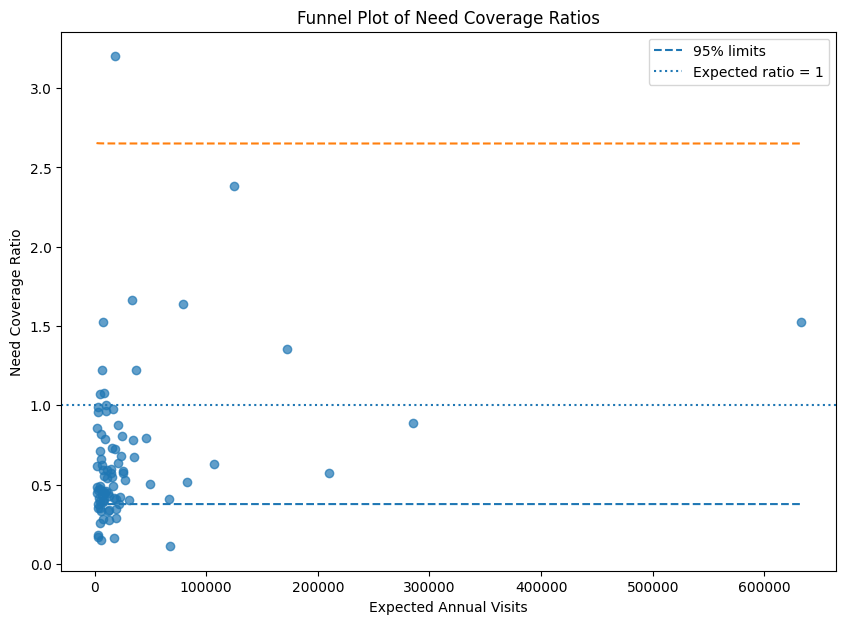

In [10]:
funnel_plot = county.sort_values(
    "expected_annual_visits"
).copy()

plt.figure(figsize=(10, 7))

plt.scatter(
    county["expected_annual_visits"],
    county["coverage_ratio"],
    alpha=0.7
)

plt.plot(
    funnel_plot["expected_annual_visits"],
    funnel_plot["lower_95_ratio"],
    linestyle="--",
    label="95% limits"
)

plt.plot(
    funnel_plot["expected_annual_visits"],
    funnel_plot["upper_95_ratio"],
    linestyle="--"
)

plt.axhline(
    1,
    linestyle=":",
    label="Expected ratio = 1"
)

plt.xlabel("Expected Annual Visits")
plt.ylabel("Need Coverage Ratio")
plt.title(
    "Funnel Plot of Need Coverage Ratios"
)

plt.legend()
plt.show()

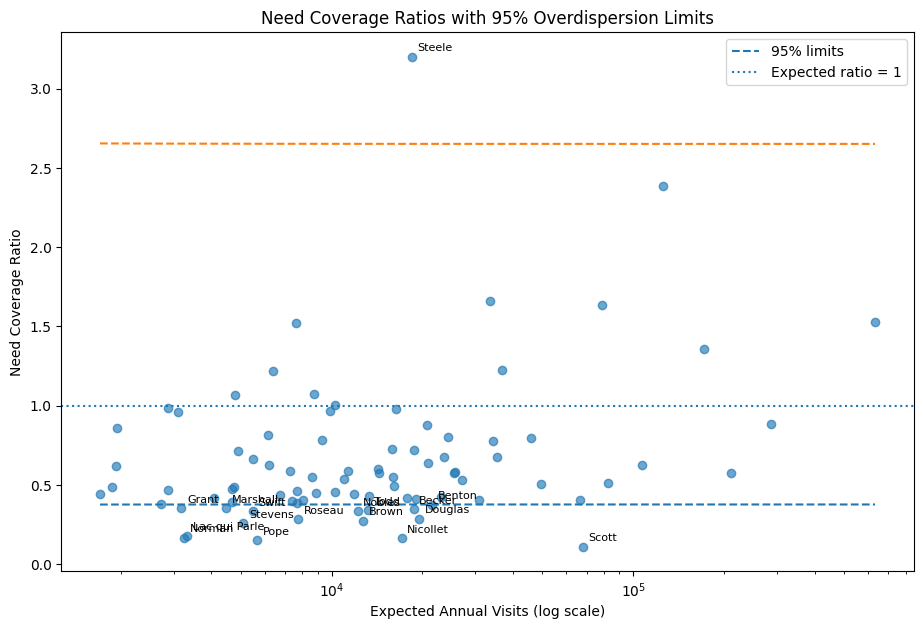

In [11]:
flagged = county[
    county["funnel_status"] != "Within limits"
].copy()

plt.figure(figsize=(11, 7))

plt.scatter(
    county["expected_annual_visits"],
    county["coverage_ratio"],
    alpha=0.65
)

plt.plot(
    funnel_plot["expected_annual_visits"],
    funnel_plot["lower_95_ratio"],
    linestyle="--",
    label="95% limits"
)

plt.plot(
    funnel_plot["expected_annual_visits"],
    funnel_plot["upper_95_ratio"],
    linestyle="--"
)

plt.axhline(
    1,
    linestyle=":",
    label="Expected ratio = 1"
)

for _, row in flagged.iterrows():
    plt.annotate(
        row["County"],
        (
            row["expected_annual_visits"],
            row["coverage_ratio"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xscale("log")

plt.xlabel("Expected Annual Visits (log scale)")
plt.ylabel("Need Coverage Ratio")
plt.title(
    "Need Coverage Ratios with 95% Overdispersion Limits"
)

plt.legend()
plt.show()

In [12]:
flagged_table = county[
    county["funnel_status"] != "Within limits"
][
    [
        "County",
        "coverage_ratio",
        "funnel_status",
        "report_share",
        "rucc",
        "main_food_bank"
    ]
].sort_values("coverage_ratio")

display(flagged_table)

,County,coverage_ratio,funnel_status,report_share,rucc,main_food_bank
68,Scott,0.111418,Below lower limit,0.950000,1,Second Harvest Heartland
60,Pope,0.150499,Below lower limit,1.000000,8,North Country Food Bank
51,Nicollet,0.165709,Below lower limit,1.000000,3,Second Harvest Heartland
53,Norman,0.168078,Below lower limit,0.958333,8,North Country Food Bank
36,Lac qui Parle,0.181299,Below lower limit,1.000000,9,Second Harvest Heartland
74,Stevens,0.260931,Below lower limit,0.750000,7,North Country Food Bank
7,Brown,0.275891,Below lower limit,1.000000,6,Second Harvest Heartland
67,Roseau,0.284817,Below lower limit,1.000000,9,North Country Food Bank
20,Douglas,0.287787,Below lower limit,1.000000,6,North Country Food Bank
75,Swift,0.334892,Below lower limit,1.000000,9,Second Harvest Heartland
